## **1. Business Understanding**
### **Tujuan proyek:**

Untuk membangun dan membandingkan model klasifikasi sentimen pada data Evaluasi Dosen oleh Mahasiswa (EDOM) di STT-NF. Komentar EDOM berisi opini mahasiswa terhadap dosen dan proses pembelajaran, yang ditulis secara bebas dengan gaya bahasa campuran, informal, serta banyak menggunakan singkatan.

### **Fokus utama:**
**1. Klasifikasi sentimen komentar EDOM:**
   - Label positif
   - Label negatif

**2. Perbandingan performa dua model klasifikasi:**
   - Model 1: IndoBERT (firqaaa/indo-sentence-bert-base) sebagai representasi teks + LinearSVC (Support Vector Machine).
   - Model 2: IndoBERT (firqaaa/indo-sentence-bert-base) sebagai representasi teks + Gaussian Naive Bayes.

**3. Analisis data menggunakan framework CRISP-DM:**
   - Business Understanding
   - Data Understanding
   - Data Preparation
   - Modeling
   - Evaluation
   - Deployment


## **2. Data Understanding**

### **Tujuan:**
**1. Load & Merge Dataset**
   - Memuat dan menggabungkan data dari kedua sheet ke dalam satu dataframe.

**2. Memahami struktur dataset:**
   - Jumlah baris (record) dan kolom.
   - Nama kolom yang tersedia.
   - Identifikasi kolom yang relevan, khususnya kolom `komentar` sebagai teks ulasan mahasiswa.

**3. Pemeriksaan kualitas data:**
   - Mengetahui jumlah nilai kosong (missing values) pada kolom `komentar`.
   - Mendeteksi adanya data duplikat.
   - Mengamati distribusi panjang komentar.

**4. Insight awal terkait karakteristik teks:**
   - Contoh beberapa komentar.
   - Variasi panjang komentar.
   - Indikasi adanya bahasa informal, singkatan, atau campuran bahasa.


In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display

# seluruh kolom terlihat saat df.head() dipanggil
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

#### **2.1 Load Dataset**

In [ ]:
# load dataset
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/My Drive/SEMESTER 7/Capstone Project/projects/datasets/edom/edom-2024.xlsx"
TEXT_COLUMN = "komentar"

df_ganjil = pd.read_excel(DATA_PATH, sheet_name="ganjil")
df_genap = pd.read_excel(DATA_PATH, sheet_name="genap")

print("Ukuran sheet 'ganjil' :", df_ganjil.shape)
print("Ukuran sheet 'genap'  :", df_genap.shape)

print("\nLima baris pertama sheet 'ganjil':")
display(df_ganjil.head())

print("\nLima baris pertama sheet 'genap':")
display(df_genap.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ukuran sheet 'ganjil' : (8580, 7)
Ukuran sheet 'genap'  : (6164, 7)

Lima baris pertama sheet 'ganjil':


,periode,nama_dosen,mata_kuliah,program studi,kategori_komentar,komentar,label_sentimen
0,2024-1,RIZKIA NURINAYANTI,pembentukan karakter,teknik informatika,open question,Tidak ada,NaN
1,2024-1,RIZKIA NURINAYANTI,pembentukan karakter,teknik informatika,open question,Semoga kedepannya lebih memperdqlam lagi ilmu ...,NaN
2,2024-1,RIZKIA NURINAYANTI,pembentukan karakter,teknik informatika,open question,Mata kuliah yang cukup menarik dan harus diter...,NaN
3,2024-1,RIZKIA NURINAYANTI,pembentukan karakter,teknik informatika,open question,Tidak ada,NaN
4,2024-1,RIZKIA NURINAYANTI,pembentukan karakter,teknik informatika,open question,Pada mata kuliah ini saya diajarkan dalam memb...,NaN



Lima baris pertama sheet 'genap':


,periode,nama_dosen,mata_kuliah,program studi,kategori_komentar,komentar,label_sentimen
0,2024-2,RIZKIA NURINAYANTI,topik khusus ti,teknik informatika,open question,terus lebih baik,NaN
1,2024-2,RIZKIA NURINAYANTI,topik khusus ti,teknik informatika,open question,-,NaN
2,2024-2,RIZKIA NURINAYANTI,topik khusus ti,teknik informatika,open question,Tidak ada,NaN
3,2024-2,RIZKIA NURINAYANTI,topik khusus ti,teknik informatika,open question,-,NaN
4,2024-2,RIZKIA NURINAYANTI,topik khusus ti,teknik informatika,open question,Mungkin kelas bisa digabung dengan jam kelas lain,NaN


#### **2.2 Merge Sheet (2024 ganjil dan genap)**

In [ ]:
df_raw = pd.concat([df_ganjil, df_genap], axis=0).reset_index(drop=True)

print("\nUkuran dataset gabungan (ganjil + genap):", df_raw.shape)
print("\nNama-nama kolom dalam dataset gabungan:")
print(df_raw.columns.tolist())

print("\nInfo singkat dataset gabungan:")
print(df_raw.info())


Ukuran dataset gabungan (ganjil + genap): (14744, 7)

Nama-nama kolom dalam dataset gabungan:
['periode', 'nama_dosen', 'mata_kuliah', 'program studi', 'kategori_komentar', 'komentar', 'label_sentimen']

Info singkat dataset gabungan:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14744 entries, 0 to 14743
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   periode            14744 non-null  object 
 1   nama_dosen         14744 non-null  object 
 2   mata_kuliah        14744 non-null  object 
 3   program studi      14744 non-null  object 
 4   kategori_komentar  14744 non-null  object 
 5   komentar           14740 non-null  object 
 6   label_sentimen     0 non-null      float64
dtypes: float64(1), object(6)
memory usage: 806.4+ KB
None


#### **2.3 Cek Missing Values pada kolom `komentar`**

In [ ]:
if TEXT_COLUMN not in df_raw.columns:
    raise ValueError(
        f"Kolom '{TEXT_COLUMN}' tidak ditemukan di dataset. "
        f"Silakan sesuaikan variabel TEXT_COLUMN dengan nama kolom komentar yang benar."
    )

missing_comments = df_raw[TEXT_COLUMN].isna().sum()
print(f"\nJumlah nilai kosong pada kolom '{TEXT_COLUMN}':", missing_comments)


Jumlah nilai kosong pada kolom 'komentar': 4


#### **2.4 Cek Duplikasi Data**

In [ ]:
duplicate_rows = df_raw.duplicated().sum()
duplicate_comments = df_raw[TEXT_COLUMN].duplicated().sum()

print("\nJumlah baris duplikat (seluruh kolom):", duplicate_rows)
print("Jumlah komentar duplikat (berdasarkan kolom komentar):", duplicate_comments)


Jumlah baris duplikat (seluruh kolom): 6447
Jumlah komentar duplikat (berdasarkan kolom komentar): 9094


#### **2.5 Distribusi Panjang Komentar (jumlah karakter)**

In [ ]:
df_raw["comment_length_chars"] = df_raw[TEXT_COLUMN].astype(str).str.len()

print("\nStatistik panjang komentar (jumlah karakter):")
print(df_raw["comment_length_chars"].describe())

print("\nContoh 5 komentar terpendek:")
display(
    df_raw.sort_values("comment_length_chars")
    .head()[[TEXT_COLUMN, "comment_length_chars"]]
)

print("\nContoh 5 komentar terpanjang:")
display(
    df_raw.sort_values("comment_length_chars", ascending=False)
    .head()[[TEXT_COLUMN, "comment_length_chars"]]
)


Statistik panjang komentar (jumlah karakter):
count    14744.000000
mean        40.899078
std         75.983659
min          1.000000
25%          1.000000
50%          9.000000
75%         50.000000
max       1171.000000
Name: comment_length_chars, dtype: float64

Contoh 5 komentar terpendek:


,komentar,comment_length_chars
9663,-,1
3430,.,1
3387,-,1
3390,-,1
3391,-,1



Contoh 5 komentar terpanjang:


,komentar,comment_length_chars
11495,"Menurut saya, mata kuliah Manajemen Proyek ini...",1171
9265,Materi teknis cenderung teoritis dan sulit dip...,1036
1481,"Secara keseluruhan, saya menilai bahwa Pak Lat...",950
12155,Mata kuliah Bahasa Inggris 1 seharusnya menjad...,942
1215,Saya merasa mata kuliah Sistem Operasi cukup m...,853


## **3. Data Preparation**

### **1. Cleaning Dataset**
   - Menghapus baris dengan komentar kosong pada kolom `komentar`.
   - Menghapus komentar yang terlalu pendek dan tidak informatif.
   - Melakukan normalisasi teks  pada kolom `komentar`:
     - Mengubah teks menjadi huruf kecil (lowercase).
     - Menghapus spasi ganda menjadi satu spasi.
     - Menghapus URL.
     - Menghapus karakter non-Latin.
     - Menghapus simbol dan emoji (non sentimen).
   Hasil cleaning disimpan di kolom baru `komentar_cleaned`.

### **2. Pelabelan Sentimen Menggunakan Model Pra-Latih (Pretrained IndoBERT Sentiment)**
   - Setiap teks pada kolom `komentar_cleaned` diprediksi menggunakan model:
     - Label mentah dari model (`Positive` atau `Negative`, atau bentuk label lain seperti `LABEL_0`/`LABEL_1`).
     - Nilai *confidence score* (probabilitas) dari model.
   - Label akhir yang digunakan:
     - Jika model memprediksi **positif** dengan skor di atas ambang batas tertentu → label **positif**.
     - Jika model memprediksi **negatif** dengan skor di atas ambang batas tertentu → label **negatif**.
     - Jika skor keyakinan model berada di bawah ambang batas (misalnya < 0,60) → label **`unknown`** (komentar dianggap tidak cukup jelas sentimennya).

### **3. Penyaringan dan Penyeimbangan Kelas (Filtering & Class Balancing)**
   - Hanya data dengan label **positif** dan **negatif** yang digunakan untuk pemodelan.
   - Data dengan label **`unknown`** dikeluarkan dari dataset training/testing karena tidak memiliki sentimen yang jelas.
   - Untuk menghindari ketidakseimbangan kelas yang terlalu besar, dilakukan balancing sederhana:
     - Melakukan *undersampling* pada kelas mayoritas sehingga jumlah data positif dan negatif menjadi relatif seimbang.

### **4. Encoding Label**
   - Mengubah label sentimen ke bentuk numerik:
     - negatif = 0
     - positif = 1

### **Outputs:**
- Bersih dari komentar kosong dan karakter non-Latin serta simbol/emoji yang tidak relevan.
- Memiliki kolom teks bersih `komentar_cleaned`.
- Memiliki kolom label sentimen biner (`label`) dengan dua kelas (0 = negatif, 1 = positif) yang sudah seimbang.
- Siap digunakan untuk proses embedding menggunakan IndoBERT dan pemodelan dengan algoritma SVM.


#### **3.1. Cleaning Dataset: hapus missing values, normalisasi, hapus non-Latin & simbol**


In [ ]:
import re
from IPython.display import display

# Salin dataframe gabungan ke df_clean untuk diolah
df_clean = df_raw.copy()

# Hapus baris dengan komentar kosong (NaN) pada kolom komentar
df_clean = df_clean.dropna(subset=[TEXT_COLUMN])

# Konversi ke string dan hilangkan spasi di awal/akhir
df_clean[TEXT_COLUMN] = df_clean[TEXT_COLUMN].astype(str).str.strip()

# Hapus komentar yang setelah strip menjadi string kosong
df_clean = df_clean[df_clean[TEXT_COLUMN] != ""]

print("Ukuran dataset setelah menghapus komentar kosong:", df_clean.shape)

def basic_text_cleaning(text: str) -> str:
    """
    Normalisasi teks untuk komentar EDOM:
    - ubah ke huruf kecil
    - hapus URL
    - hapus karakter non-Latin (Cina, Jepang, Arab, dll) dan simbol/emoji
    - sisakan huruf a-z, angka, dan spasi
    - rapikan spasi berlebih
    """
    # Lowercase
    text = text.lower()

    # Hapus URL
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # Hapus seluruh karakter yang bukan huruf latin, angka, atau spasi
    # [^a-z0-9\s] artinya: selain a-z, 0-9, dan spasi
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Ganti spasi berurutan jadi satu spasi
    text = re.sub(r"\s+", " ", text)

    # Hapus spasi di awal dan akhir
    text = text.strip()

    return text

# Apply cleaning ke kolom komentar dan simpan di kolom baru
df_clean["komentar_cleaned"] = df_clean[TEXT_COLUMN].apply(basic_text_cleaning)

print("\nContoh hasil cleaning (5 baris pertama):")
display(df_clean[[TEXT_COLUMN, "komentar_cleaned"]].head())

Ukuran dataset setelah menghapus komentar kosong: (14740, 8)

Contoh hasil cleaning (5 baris pertama):


,komentar,komentar_cleaned
0,Tidak ada,tidak ada
1,Semoga kedepannya lebih memperdqlam lagi ilmu ...,semoga kedepannya lebih memperdqlam lagi ilmu ...
2,Mata kuliah yang cukup menarik dan harus diter...,mata kuliah yang cukup menarik dan harus diter...
3,Tidak ada,tidak ada
4,Pada mata kuliah ini saya diajarkan dalam memb...,pada mata kuliah ini saya diajarkan dalam memb...


#### **3.2 Menghapus komentar terlalu pendek (tidak informatif)**

In [ ]:
# Hitung jumlah kata pada komentar_cleaned
df_clean["word_count"] = df_clean["komentar_cleaned"].str.split().apply(len)

print("Statistik jumlah kata per komentar setelah cleaning:")
print(df_clean["word_count"].describe())

# Buang komentar dengan jumlah kata < 3
MIN_WORDS = 3
df_clean = df_clean[df_clean["word_count"] >= MIN_WORDS]

print("\nUkuran dataset setelah menghapus komentar dengan jumlah kata <",
      MIN_WORDS, ":", df_clean.shape)

print("\nContoh 5 komentar setelah filter jumlah kata minimal:")
display(df_clean[[TEXT_COLUMN, "komentar_cleaned", "word_count"]].head())

Statistik jumlah kata per komentar setelah cleaning:
count    14740.000000
mean         6.072049
std         10.858506
min          0.000000
25%          0.000000
50%          2.000000
75%          7.000000
max        165.000000
Name: word_count, dtype: float64

Ukuran dataset setelah menghapus komentar dengan jumlah kata < 3 : (6247, 10)

Contoh 5 komentar setelah filter jumlah kata minimal:


,komentar,komentar_cleaned,word_count
1,Semoga kedepannya lebih memperdqlam lagi ilmu ...,semoga kedepannya lebih memperdqlam lagi ilmu ...,8
2,Mata kuliah yang cukup menarik dan harus diter...,mata kuliah yang cukup menarik dan harus diter...,11
4,Pada mata kuliah ini saya diajarkan dalam memb...,pada mata kuliah ini saya diajarkan dalam memb...,22
5,"Penerapan nya udh bagus, jdi saya sebagai maha...",penerapan nya udh bagus jdi saya sebagai mahas...,23
6,Seru sih walaupun kadang bikin ngantuk karena ...,seru sih walaupun kadang bikin ngantuk karena ...,12


#### **3.3 Load Pretrained IndoBERT Sentiment Model (binary POS/NEG)**

In [ ]:
# install library
!pip install -q transformers

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

# indobert khusus labeling saja
SENTIMENT_MODEL_NAME = "agufsamudra/indo-sentiment-analysis"

# Load tokenizer & model
tokenizer_sent = AutoTokenizer.from_pretrained(SENTIMENT_MODEL_NAME)
model_sent = AutoModelForSequenceClassification.from_pretrained(SENTIMENT_MODEL_NAME)

device = 0 if torch.cuda.is_available() else -1

sentiment_clf = pipeline(
    "text-classification",
    model=model_sent,
    tokenizer=tokenizer_sent,
    device=device
)

print("Model sentiment berhasil dimuat:", SENTIMENT_MODEL_NAME)

Device set to use cuda:0


Model sentiment berhasil dimuat: agufsamudra/indo-sentiment-analysis


#### **3.4 Prediksi sentimen untuk setiap komentar (semi-supervised labeling)**

In [ ]:
texts = df_clean["komentar_cleaned"].tolist()
print("Jumlah komentar yang akan diprediksi:", len(texts))

# Pipeline memproses list teks (otomatis batch)
results = sentiment_clf(texts, batch_size=32, truncation=True)

# Simpan label mentah & skor confidence
df_clean["sentiment_model_label_raw"] = [r["label"] for r in results]
df_clean["sentiment_model_score"] = [r["score"] for r in results]

print("\nContoh hasil prediksi model (5 baris):")
display(
    df_clean[
        [TEXT_COLUMN, "komentar_cleaned", "sentiment_model_label_raw", "sentiment_model_score"]
    ].head()
)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Jumlah komentar yang akan diprediksi: 6247

Contoh hasil prediksi model (5 baris):


,komentar,komentar_cleaned,sentiment_model_label_raw,sentiment_model_score
1,Semoga kedepannya lebih memperdqlam lagi ilmu ...,semoga kedepannya lebih memperdqlam lagi ilmu ...,LABEL_1,0.974485
2,Mata kuliah yang cukup menarik dan harus diter...,mata kuliah yang cukup menarik dan harus diter...,LABEL_1,0.898370
4,Pada mata kuliah ini saya diajarkan dalam memb...,pada mata kuliah ini saya diajarkan dalam memb...,LABEL_1,0.925860
5,"Penerapan nya udh bagus, jdi saya sebagai maha...",penerapan nya udh bagus jdi saya sebagai mahas...,LABEL_1,0.931809
6,Seru sih walaupun kadang bikin ngantuk karena ...,seru sih walaupun kadang bikin ngantuk karena ...,LABEL_1,0.740965


#### **3.5 Mapping label model: positif/negatif**

In [ ]:
# Label unknown akan di drop unknown untuk modeling, balancing, dan encoding

def map_model_label_to_sentiment(label_str: str) -> str:
    """
    Mengubah label mentah dari model HuggingFace ke 'positif' / 'negatif':
    - Jika mengandung 'neg' atau '0' -> negatif
    - Jika mengandung 'pos' atau '1' -> positif
    Selain itu -> unknown
    """
    label_lower = label_str.lower()
    if "neg" in label_lower or "0" in label_lower:
        return "negatif"
    if "pos" in label_lower or "1" in label_lower:
        return "positif"
    return "unknown"

CONFIDENCE_THRESHOLD = 0.6

def final_sentiment_label(row):
    """
    Menentukan label akhir dengan mempertimbangkan:
    - label mentah dari model
    - confidence score
    """
    base_label = map_model_label_to_sentiment(row["sentiment_model_label_raw"])
    score = row["sentiment_model_score"]

    # Jika confidence kurang dari threshold, anggap unknown
    if score < CONFIDENCE_THRESHOLD:
        return "unknown"
    return base_label

# Terapkan fungsi untuk mendapatkan label akhir
df_clean["sentiment_label"] = df_clean.apply(final_sentiment_label, axis=1)

print("Distribusi label (termasuk unknown):")
print(df_clean["sentiment_label"].value_counts())

Distribusi label (termasuk unknown):
sentiment_label
positif    4163
negatif    1629
unknown     455
Name: count, dtype: int64


In [ ]:
# 3.5.2 Penyesuaian rule-based untuk komentar non-sentimen

import re
NO_FEEDBACK_KEYWORDS = ["masukan", "saran", "kritik", "kiritik", "komentar"]

def adjust_no_feedback_labels(row):
    t = row["komentar_cleaned"].lower()
    label = row["sentiment_label"]

    # jika mengandung "tidak ada + kata kunci"
    if "tidak ada" in t and any(k in t for k in NO_FEEDBACK_KEYWORDS):

        # jika ada kata positif → jadikan positif
        if "bagus" in t or "baik" in t or "cukup" in t:
            return "positif"

        # selain itu → tidak jelas → unknown
        return "unknown"

    # jika bukan kasus khusus → pakai label model
    return label

df_clean["sentiment_label"] = df_clean.apply(adjust_no_feedback_labels, axis=1)

print("Distribusi label setelah penyesuaian rule-based:")
print(df_clean["sentiment_label"].value_counts())

Distribusi label setelah penyesuaian rule-based:
sentiment_label
positif    4171
negatif    1511
unknown     565
Name: count, dtype: int64


#### **3.6 Filter hanya positif & negatif, balancing, dan encoding**

In [ ]:
# Hanya gunakan data dengan label positif & negatif
df_labeled = df_clean[df_clean["sentiment_label"].isin(["positif", "negatif"])].copy()

print("Distribusi label setelah mengeluarkan 'unknown':")
print(df_labeled["sentiment_label"].value_counts())

# Balancing sederhana: undersampling kelas mayoritas
class_counts = df_labeled["sentiment_label"].value_counts()
min_count = class_counts.min()

print("\nJumlah data tiap kelas sebelum balancing:")
for label, count in class_counts.items():
    print(f" - {label}: {count}")

print("\nUkuran target tiap kelas setelah balancing (undersampling):", min_count)

dfs_balanced = []
for label in class_counts.index:
    df_label = df_labeled[df_labeled["sentiment_label"] == label]
    df_label_sampled = df_label.sample(n=min_count, random_state=42)
    dfs_balanced.append(df_label_sampled)

df_balanced = (
    pd.concat(dfs_balanced, axis=0)
    .sample(frac=1.0, random_state=42)
    .reset_index(drop=True)
)

print("\nDistribusi label setelah balancing:")
print(df_balanced["sentiment_label"].value_counts())

# Konversi label ke bentuk numerik (0/1) untuk modeling
# negatif = 0, positif = 1
label_mapping = {"negatif": 0, "positif": 1}
df_balanced["label"] = df_balanced["sentiment_label"].map(label_mapping)

print("\nContoh 10 baris data siap modeling:")
display(
    df_balanced[
        [TEXT_COLUMN, "komentar_cleaned", "sentiment_model_label_raw",
         "sentiment_model_score", "sentiment_label", "label"]
    ].head(10)
)

Distribusi label setelah mengeluarkan 'unknown':
sentiment_label
positif    4171
negatif    1511
Name: count, dtype: int64

Jumlah data tiap kelas sebelum balancing:
 - positif: 4171
 - negatif: 1511

Ukuran target tiap kelas setelah balancing (undersampling): 1511

Distribusi label setelah balancing:
sentiment_label
positif    1511
negatif    1511
Name: count, dtype: int64

Contoh 10 baris data siap modeling:


,komentar,komentar_cleaned,sentiment_model_label_raw,sentiment_model_score,sentiment_label,label
0,"Terima kasih pak, sehat terus dan semoga ilmun...",terima kasih pak sehat terus dan semoga ilmuny...,LABEL_1,0.988184,positif,1
1,Mata Kuliah ini sudah berjalan dengan sangat baik,mata kuliah ini sudah berjalan dengan sangat baik,LABEL_1,0.891913,positif,1
2,Seru dan Asik,seru dan asik,LABEL_1,0.991663,positif,1
3,"Sangat baik, semangat Bu Tiffany. Terimakasih ...",sangat baik semangat bu tiffany terimakasih at...,LABEL_1,0.989844,positif,1
4,Dosen sebaiknya upload materi terlebih dahulu ...,dosen sebaiknya upload materi terlebih dahulu ...,LABEL_1,0.843581,positif,1
5,mata kuliah ini harus dikembangkan terus untuk...,mata kuliah ini harus dikembangkan terus untuk...,LABEL_1,0.737553,positif,1
6,"Cara ajar Pak Latief sudah sangat baik, jawaba...",cara ajar pak latief sudah sangat baik jawaban...,LABEL_1,0.855062,positif,1
7,terimakasih atas satu semesternya🙏🤍,terimakasih atas satu semesternya,LABEL_1,0.947829,positif,1
8,Kelas dimulai dan diakhiri tepat waktu mungkin...,kelas dimulai dan diakhiri tepat waktu mungkin...,LABEL_0,0.943345,negatif,0
9,Penyampaian materi jelas dan kadang disertai d...,penyampaian materi jelas dan kadang disertai d...,LABEL_0,0.634397,negatif,0


#### **3.7 Simpan Dataset Hasil Cleaning & Labeling**

In [ ]:
# Simpan dataset hasil cleaning & labeling (file CSV)
OUTPUT_PATH = "/content/drive/My Drive/SEMESTER 7/Capstone Project/projects/datasets/edom/edom-2024-clean-balanced.csv"

df_balanced.to_csv(OUTPUT_PATH, index=False)
print("Dataset cleaned & labeled tersimpan di:", OUTPUT_PATH)

Dataset cleaned & labeled tersimpan di: /content/drive/My Drive/SEMESTER 7/Capstone Project/projects/datasets/edom/edom-2024-clean-balanced.csv


In [ ]:
# Simpan dataset hasil cleaning & labeling (file EXCEL)
OUTPUT_XLSX = "/content/drive/My Drive/SEMESTER 7/Capstone Project/projects/datasets/edom/edom-2024-clean-balanced.xlsx"

df_balanced.to_excel(OUTPUT_XLSX, index=False)
print("Dataset cleaned & labeled tersimpan di:", OUTPUT_XLSX)

Dataset cleaned & labeled tersimpan di: /content/drive/My Drive/SEMESTER 7/Capstone Project/projects/datasets/edom/edom-2024-clean-balanced.xlsx


## **4. Modeling: IndoBERT (Sentence-BERT) + LinearSVC dan Gaussian Naive Bayes**

Pemodelan klasifikasi sentimen dilakukan menggunakan dua algoritma berbeda dengan representasi teks yang sama, yaitu **IndoBERT Sentence-BERT** (`firqaaa/indo-sentence-bert-base`). Model ini mengubah setiap komentar menjadi vektor embedding berdimensi tetap, sehingga dapat diproses oleh algoritma machine learning klasik.

Pendekatan ini menghasilkan dua kombinasi model yang akan dibandingkan:

- **Model 1:** IndoBERT Sentence-BERT + **LinearSVC (SVM)**
- **Model 2:** IndoBERT Sentence-BERT + **Gaussian Naive Bayes (GaussianNB)**

Kedua model dilatih dan diuji menggunakan dataset yang sama, sehingga memungkinkan perbandingan performa yang objektif.

---

### **Tahapan Pemodelan**

#### **1. Memuat Dataset Hasil Cleaning & Labeling**
Dataset yang digunakan merupakan hasil dari tahap Data Preparation, yang telah melalui:
- pembersihan teks (normalisasi, pembuangan karakter non-Latin, simbol, dan komentar sangat pendek),
- pelabelan sentimen menggunakan pretrained IndoBERT sentiment dengan penyesuaian rule-based,
- balancing kelas menggunakan undersampling.

Kolom utama yang digunakan:
- `komentar_cleaned` → teks komentar yang telah dibersihkan,
- `label` → label numerik sentimen (0 = negatif, 1 = positif).

Dataset ini memastikan seluruh model dilatih pada data yang bersih, konsisten, dan seimbang.

---

#### **2. Pembagian Data (Train–Test Split)**
Data dibagi menjadi:
- **80%** data latih,
- **20%** data uji.

Pembagian dilakukan secara **stratified** berdasarkan label, sehingga proporsi kelas tetap seimbang pada data latih maupun data uji. Hal ini memastikan evaluasi model lebih objektif dan tidak bias kelas.

---

#### **3. Ekstraksi Fitur Menggunakan IndoBERT Sentence-BERT**
Model `firqaaa/indo-sentence-bert-base` digunakan untuk menghasilkan **embedding** dari setiap komentar.

Setiap teks diubah menjadi vektor berdimensi tetap (±768 dimensi) yang merepresentasikan konteks dan makna komentar. Embedding dihitung secara terpisah untuk data latih dan data uji, dan digunakan sebagai input bagi kedua algoritma klasifikasi.

Pendekatan ini meningkatkan kualitas representasi teks sehingga model SVM maupun Naive Bayes dapat bekerja lebih efektif.

---

#### **4. Pelatihan Dua Model Klasifikasi**

##### **a. LinearSVC (SVM)**
Model Linear Support Vector Classification dilatih menggunakan embedding IndoBERT.  
Alasan pemilihan:
- performa sangat baik pada data berdimensi tinggi,
- stabil dalam menangani teks pendek dan gaya bahasa informal,
- umum digunakan dalam tugas klasifikasi sentimen.

---

##### **b. Gaussian Naive Bayes (GaussianNB)**
Model GaussianNB dilatih dengan input embedding yang sama.  
Alasan pemilihan:
- sederhana, ringan, dan sangat cepat dilatih,
- menangani fitur kontinu,
- berfungsi sebagai baseline pembanding terhadap model yang lebih kompleks, seperti SVM.

---

#### **5. Evaluasi Model**
Kedua model diuji menggunakan data uji yang tidak digunakan pada saat pelatihan.  
Evaluasi dilakukan menggunakan empat metrik kuantitatif utama:

- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**

Selain itu, setiap model ditampilkan **confusion matrix** untuk melihat distribusi prediksi benar dan salah per kelas (positif/negatif).

#### **4.1 Load Dataset Hasil Cleaning & Labeling**

In [1]:
import pandas as pd
from IPython.display import display

# load dataset
from google.colab import drive
drive.mount('/content/drive')

# Load dataset hasil preparation
DATASET_PATH = "/content/drive/My Drive/SEMESTER 7/Capstone Project/projects/datasets/edom/edom-2024-clean-balanced.csv"

# Membaca dataset
df = pd.read_csv(DATASET_PATH)

print("Ukuran dataset:", df.shape)
print("\nNama kolom:")
print(df.columns.tolist())

print("\nLima baris pertama dataset:")
display(df.head())

# Kolom yang akan digunakan untuk modeling
TEXT_COLUMN = "komentar_cleaned"   # fitur teks
LABEL_COLUMN = "label"             # target numerik (0/1)

# Cek apakah kolom ada
for col in [TEXT_COLUMN, LABEL_COLUMN]:
    if col not in df.columns:
        raise ValueError(f"Kolom '{col}' tidak ditemukan di dataset. Sesuaikan nama kolomnya.")

Mounted at /content/drive
Ukuran dataset: (3022, 14)

Nama kolom:
['periode', 'nama_dosen', 'mata_kuliah', 'program studi', 'kategori_komentar', 'komentar', 'label_sentimen', 'comment_length_chars', 'komentar_cleaned', 'word_count', 'sentiment_model_label_raw', 'sentiment_model_score', 'sentiment_label', 'label']

Lima baris pertama dataset:


,periode,nama_dosen,mata_kuliah,program studi,kategori_komentar,komentar,label_sentimen,comment_length_chars,komentar_cleaned,word_count,sentiment_model_label_raw,sentiment_model_score,sentiment_label,label
0,2024-2,EFRIZAL ZAIDA,keamanan komputer dan jaringan,teknik informatika,kritik & saran,"Terima kasih pak, sehat terus dan semoga ilmun...",NaN,55,terima kasih pak sehat terus dan semoga ilmuny...,9,LABEL_1,0.988184,positif,1
1,2024-1,AHMAD RIO ADRIANSYAH,natural language processing,teknik informatika,open question,Mata Kuliah ini sudah berjalan dengan sangat baik,NaN,49,mata kuliah ini sudah berjalan dengan sangat baik,8,LABEL_1,0.891913,positif,1
2,2024-2,Maulana Fakih Latief,jaringan komputer,sistem informasi,open question,Seru dan Asik,NaN,13,seru dan asik,3,LABEL_1,0.991663,positif,1
3,2024-1,TIFANNY NABARIAN,rekayasa perangkat lunak,teknik informatika,kritik & saran,"Sangat baik, semangat Bu Tiffany. Terimakasih ...",NaN,61,sangat baik semangat bu tiffany terimakasih at...,8,LABEL_1,0.989844,positif,1
4,2024-1,SIROJUL MUNIR,sistem informasi geografis,teknik informatika,open question,Dosen sebaiknya upload materi terlebih dahulu ...,NaN,168,dosen sebaiknya upload materi terlebih dahulu ...,25,LABEL_1,0.843581,positif,1


#### **4.2 Train–Test Split**

In [2]:
from sklearn.model_selection import train_test_split

# Fitur teks dan target
X_text = df[TEXT_COLUMN].astype(str).tolist()
y = df[LABEL_COLUMN].astype(int)

# Bagi data train dan test (80:20)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # supaya proporsi kelas seimbang di train & test
)

print("Jumlah data training :", len(X_train_text))
print("Jumlah data testing  :", len(X_test_text))

Jumlah data training : 2417
Jumlah data testing  : 605


#### **4.3 Load Model IndoBERT Sentence-BERT untuk Embedding**

In [3]:
# install library
!pip install -q sentence-transformers

In [4]:
from sentence_transformers import SentenceTransformer
import numpy as np
import torch

EMBEDDING_MODEL_NAME = "firqaaa/indo-sentence-bert-base"

# Load model
sbert_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"
sbert_model.to(device)

print("Model embedding berhasil dimuat:", EMBEDDING_MODEL_NAME)
print("Perangkat yang digunakan:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/118 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model embedding berhasil dimuat: firqaaa/indo-sentence-bert-base
Perangkat yang digunakan: cuda


#### **4.4 Menghasilkan Embedding IndoBERT untuk Data Train & Test**

In [5]:
# Fungsi helper untuk encode dengan batch
def encode_texts(model, texts, batch_size=32):
    """
    Meng-encode list teks menjadi embedding numpy array
    menggunakan SentenceTransformer.
    """
    embeddings = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        device=device
    )
    return embeddings

# Generate embeddings
X_train_embed = encode_texts(sbert_model, X_train_text, batch_size=32)
X_test_embed  = encode_texts(sbert_model, X_test_text, batch_size=32)

print("Shape embedding train:", X_train_embed.shape)
print("Shape embedding test :", X_test_embed.shape)

Batches:   0%|          | 0/76 [00:00<?, ?it/s]

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Shape embedding train: (2417, 768)
Shape embedding test : (605, 768)


#### **4.5 Pelatihan Model LinearSVC (SVM)**

In [6]:
from sklearn.svm import LinearSVC

# Inisialisasi model LinearSVC
svm_model = LinearSVC(
    C=1.0,
    max_iter=5000,
    random_state=42
)

# Training
svm_model.fit(X_train_embed, y_train)

print("Training LinearSVC selesai.")

Training LinearSVC selesai.


In [7]:
print("Bobot (w):", svm_model.coef_)
print("Bias (b):", svm_model.intercept_)

Bobot (w): [[-9.00831650e-02 -1.48663735e-01 -3.25021789e-01 -9.87215234e-03
  -2.25022794e-01 -4.51865250e-03  5.55094105e-02 -2.35688363e-01
  -2.21377903e-02  1.06996321e-01  5.89475838e-02 -4.11347579e-02
  -1.92395685e-01  1.18525176e-01 -8.42259675e-02  4.38611983e-01
  -8.86926782e-02 -5.08502475e-02 -1.71553369e-01  2.33628515e-01
   3.48695566e-01 -3.94348293e-01 -1.89549603e-01  8.00046185e-02
  -2.28783931e-02  2.83119805e-01 -2.31984313e-01  2.27332476e-01
   3.93773801e-01  1.22135272e-01 -1.53631665e-01  1.94063080e-02
   5.01625138e-01  1.86399044e-01  3.83415051e-01 -1.32714504e-01
  -3.57430023e-01  2.85605721e-01 -2.53105907e-02  7.38570779e-02
  -3.53191010e-02 -1.01526444e-01  2.76543810e-01  1.82306735e-01
  -1.54304009e-02 -5.08798600e-02 -3.89001762e-01 -3.50919416e-01
   6.07374731e-02  3.54850076e-01 -2.76081245e-02 -5.14384367e-01
   1.18781618e-02 -2.42553539e-01  4.89112315e-02  1.37028366e-01
  -1.64630025e-01  2.37436353e-01 -1.95508545e-01  5.01701062e-02

#### **4.6 Pelatihan Model GaussianNB (Naive Bayes)**

In [8]:
from sklearn.naive_bayes import GaussianNB

# Inisialisasi model GaussianNB
gnb_model = GaussianNB()

# Latih model dengan embedding IndoBERT (train set)
gnb_model.fit(X_train_embed, y_train)

print("Training Gaussian Naive Bayes selesai.")

Training Gaussian Naive Bayes selesai.


## **5. Evaluasi Model**

Evaluasi ini memastikan bahwa model mampu bekerja secara optimal pada data yang belum pernah dilihat sebelumnya serta memberikan gambaran menyeluruh terkait kelebihan dan keterbatasan model.

### **Tahapan Evaluasi:**

#### **1. Evaluasi Menggunakan Metrik Klasifikasi (Classification Report)**
   - Prediksi dilakukan pada data uji yang sebelumnya dipisahkan menggunakan *train–test split*.
   - Metrik yang digunakan:
     - **Accuracy** → tingkat keseluruhan prediksi benar.
     - **Precision** → ketepatan model dalam memprediksi kelas tertentu.
     - **Recall** → kemampuan model menangkap seluruh data dari tiap kelas.
     - **F1-score** → rata-rata harmonik precision dan recall.
   - Metrik ini memberikan gambaran menyeluruh mengenai performa model pada masing-masing kelas (positif dan negatif).

#### **2. Confusion Matrix**
   - Confusion matrix digunakan untuk melihat pola prediksi model secara lebih detail.
   - Menampilkan jumlah:
     - True Positive (TP)
     - True Negative (TN)
     - False Positive (FP)
     - False Negative (FN)
   - Visualisasi ini membantu mengidentifikasi apakah model cenderung bias terhadap salah satu kelas atau memiliki kesalahan yang dominan pada tipe tertentu.

#### **3. Error Analysis (Analisis Kesalahan)**
   - Melakukan inspeksi manual terhadap beberapa contoh prediksi yang salah.
   - Tujuannya adalah untuk mengidentifikasi pola komentar yang sulit diklasifikasikan model, seperti:
     - kalimat ambigu,
     - komentar netral,
     - atau komentar dengan struktur non-standar.
   - Analisis ini penting untuk memahami batasan model dan menjadi dasar dalam penyempurnaan atau penerapan *rule-based* pada tahap inferensi.

#### **4. Distribution Check (Pemeriksaan Sebaran Label)**
   - Mengecek distribusi label pada data latih dan data uji setelah proses balancing.
   - Tujuannya memastikan bahwa:
     - dataset tidak bias,
     - pembagian train–test sudah seimbang,
     - dan model dilatih pada representasi data yang konsisten.
   - Tahap ini mendukung validitas metrik evaluasi yang dihasilkan.

#### **5.1 Evaluasi & Perbandingan: IndoBERT + SVM vs IndoBERT + Naive Bayes**

In [9]:
# Evaluasi & Perbandingan: IndoBERT + SVM vs IndoBERT + GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
import numpy as np
import pandas as pd

label_id_to_name = {0: "negatif", 1: "positif"}

def evaluate_model(model_name, model, X_test_embed, y_test):
    """
    Menghitung metrik evaluasi untuk satu model:
    - Accuracy
    - Precision per kelas
    - Recall per kelas
    - F1-score per kelas
    - Confusion matrix
    Serta menampilkan classification report & confusion matrix.
    Mengembalikan dict ringkasan metrik untuk dibandingkan antar model.
    """
    # Prediksi
    y_pred = model.predict(X_test_embed)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    # Precision, Recall, F1 per kelas (0 = negatif, 1 = positif)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test,
        y_pred,
        labels=[0, 1],
        zero_division=0
    )

    print(f"\n==============================")
    print(f"=== Evaluasi Model: {model_name} ===")
    print(f"==============================")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision (negatif, positif): {np.round(precision, 4)}")
    print(f"Recall    (negatif, positif): {np.round(recall, 4)}")
    print(f"F1-score  (negatif, positif): {np.round(f1, 4)}")
    print(f"Support   (negatif, positif): {support}")

    print("\n--- Classification Report ---")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["negatif", "positif"],
            zero_division=0
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    cm_df = pd.DataFrame(
        cm,
        index=["Actual Negatif", "Actual Positif"],
        columns=["Pred Negatif", "Pred Positif"]
    )

    print("\n--- Confusion Matrix ---")
    display(cm_df)

    # Kembalikan ringkasan metrik untuk dibandingkan
    return {
        "model": model_name,
        "accuracy": acc,
        "precision_neg": precision[0],
        "precision_pos": precision[1],
        "recall_neg": recall[0],
        "recall_pos": recall[1],
        "f1_neg": f1[0],
        "f1_pos": f1[1],
    }

# Panggil evaluasi untuk kedua model
results = []
results.append(evaluate_model("IndoBERT + LinearSVC (SVM)", svm_model, X_test_embed, y_test))
results.append(evaluate_model("IndoBERT + GaussianNB", gnb_model, X_test_embed, y_test))

# Buat tabel ringkasan perbandingan
comparison_df = pd.DataFrame(results)
print("\n==============================")
print("Ringkasan Perbandingan Model")
print("==============================")
display(comparison_df)


=== Evaluasi Model: IndoBERT + LinearSVC (SVM) ===
Accuracy  : 0.9388
Precision (negatif, positif): [0.9524 0.926 ]
Recall    (negatif, positif): [0.9241 0.9536]
F1-score  (negatif, positif): [0.938  0.9396]
Support   (negatif, positif): [303 302]

--- Classification Report ---
              precision    recall  f1-score   support

     negatif       0.95      0.92      0.94       303
     positif       0.93      0.95      0.94       302

    accuracy                           0.94       605
   macro avg       0.94      0.94      0.94       605
weighted avg       0.94      0.94      0.94       605


--- Confusion Matrix ---


,Pred Negatif,Pred Positif
Actual Negatif,280,23
Actual Positif,14,288



=== Evaluasi Model: IndoBERT + GaussianNB ===
Accuracy  : 0.9240
Precision (negatif, positif): [0.8954 0.9571]
Recall    (negatif, positif): [0.9604 0.8874]
F1-score  (negatif, positif): [0.9268 0.921 ]
Support   (negatif, positif): [303 302]

--- Classification Report ---
              precision    recall  f1-score   support

     negatif       0.90      0.96      0.93       303
     positif       0.96      0.89      0.92       302

    accuracy                           0.92       605
   macro avg       0.93      0.92      0.92       605
weighted avg       0.93      0.92      0.92       605


--- Confusion Matrix ---


,Pred Negatif,Pred Positif
Actual Negatif,291,12
Actual Positif,34,268



Ringkasan Perbandingan Model


,model,accuracy,precision_neg,precision_pos,recall_neg,recall_pos,f1_neg,f1_pos
0,IndoBERT + LinearSVC (SVM),0.938843,0.952381,0.926045,0.924092,0.953642,0.938023,0.939641
1,IndoBERT + GaussianNB,0.923967,0.895385,0.957143,0.960396,0.887417,0.926752,0.920962


**Error Analysis**

In [11]:
# ============================================
# ERROR ANALYSIS - MODEL TERBAIK (SVM)
# ============================================

import pandas as pd
import numpy as np

# Prediksi
y_pred = svm_model.predict(X_test_embed)

# Pastikan semua data dalam format list (biar aman)
X_text = list(X_test_text)
y_true = list(y_test)
y_pred = list(y_pred)

# Buat dataframe
error_df = pd.DataFrame({
    "komentar": X_text,
    "label_asli": y_true,
    "prediksi": y_pred
})

# Mapping label (biar lebih readable)
label_map = {0: "negatif", 1: "positif"}
error_df["label_asli"] = error_df["label_asli"].map(label_map)
error_df["prediksi"] = error_df["prediksi"].map(label_map)

# Ambil error
errors = error_df[error_df["label_asli"] != error_df["prediksi"]]

# Statistik error
print("Jumlah data uji :", len(error_df))
print("Jumlah error    :", len(errors))
print("Error rate      :", round(len(errors) / len(error_df), 4))

# Tampilkan contoh error
print("\nContoh kesalahan prediksi:")
display(errors.sample(min(10, len(errors)), random_state=42))

Jumlah data uji : 605
Jumlah error    : 37
Error rate      : 0.0612

Contoh kesalahan prediksi:


,komentar,label_asli,prediksi
267,materi jaringan komputer cukup menarik namun p...,negatif,positif
202,bimbingan terjadwal untuk project yang dilaksa...,negatif,positif
53,tidak ada pendapat saya mengenai mata kuliah i...,positif,negatif
485,semoga bisa lebih baik lagi kedepannya dalam h...,negatif,positif
548,kalau bisa kuliah online,negatif,positif
405,untuk dosennya baik dan pengertian terhadap ma...,positif,negatif
87,matkul ini susah susah mudah tapi bikin penasaran,negatif,positif
425,saran kelas online lebih baik diminimalisir,negatif,positif
372,tidak ada yang ingin saya sampaikan dosen suda...,negatif,positif
261,dalam sesi praktikum saya harap beliau dapat m...,negatif,positif


In [13]:
# ============================================
# KATEGORI ERROR
# ============================================

def categorize_error(text):
    text = str(text).lower()

    if len(text.split()) <= 3:
        return "komentar pendek"
    elif "tidak" in text or "kurang" in text:
        return "potensi ambiguitas"
    elif "dan" in text:
        return "multi-sentimen"
    else:
        return "lainnya"

errors = errors.copy()
errors["kategori"] = errors["komentar"].apply(categorize_error)

# Distribusi error
print("\nDistribusi jenis error:")
display(errors["kategori"].value_counts())


Distribusi jenis error:


,count
kategori,
potensi ambiguitas,15
lainnya,14
multi-sentimen,7
komentar pendek,1


**Uji Statistik (McNemar Test)**

In [15]:
pip install statsmodels

In [18]:
# ============================================
# UJI STATISTIK: MCNEMAR TEST
# ============================================

from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

# Prediksi kedua model
y_pred_svm = svm_model.predict(X_test_embed)
y_pred_nb = gnb_model.predict(X_test_embed)

# Pastikan semua dalam bentuk array/list
y_true = np.array(y_test)
y_pred_svm = np.array(y_pred_svm)
y_pred_nb = np.array(y_pred_nb)

# ============================================
# Hitung nilai b dan c
# b = SVM benar, NB salah
# c = SVM salah, NB benar
# ============================================

b = np.sum((y_pred_svm == y_true) & (y_pred_nb != y_true))
c = np.sum((y_pred_svm != y_true) & (y_pred_nb == y_true))

# Buat tabel kontingensi 2x2
table = [[0, b],
         [c, 0]]

print("Tabel McNemar:")
print(np.array(table))

# ============================================
# Jalankan McNemar Test
# ============================================

result = mcnemar(table, exact=True)

print("\nHasil McNemar Test:")
print("Statistic :", result.statistic)
print("p-value   :", result.pvalue)

# ============================================
# INTERPRETASI OTOMATIS
# ============================================
alpha = 0.05

print("\nInterpretasi:")

if result.pvalue < alpha:
    print("Perbedaan performa antara model SVM dan Naive Bayes menunjukkan perbedaan yang signifikan secara statistik (p < 0.05).")
    print("Hal ini mengindikasikan bahwa salah satu model memiliki keunggulan yang kuat secara statistik.")
else:
    print("Perbedaan performa antara model SVM dan Naive Bayes belum menunjukkan perbedaan yang cukup kuat secara statistik (p >= 0.05).")
    print("Meskipun demikian, model SVM tetap menunjukkan performa yang lebih baik secara konsisten berdasarkan metrik evaluasi.")

print("\nCatatan:")
print("Secara empiris, model SVM memiliki nilai accuracy dan F1-score yang lebih tinggi dibandingkan Naive Bayes.")


Tabel McNemar:
[[ 0 28]
 [19  0]]

Hasil McNemar Test:
Statistic : 19.0
p-value   : 0.24296021728332556

Interpretasi:
Perbedaan performa antara model SVM dan Naive Bayes belum menunjukkan perbedaan yang cukup kuat secara statistik (p >= 0.05).
Meskipun demikian, model SVM tetap menunjukkan performa yang lebih baik secara konsisten berdasarkan metrik evaluasi.

Catatan:
Secara empiris, model SVM memiliki nilai accuracy dan F1-score yang lebih tinggi dibandingkan Naive Bayes.


**Visualisasi Distribusi**

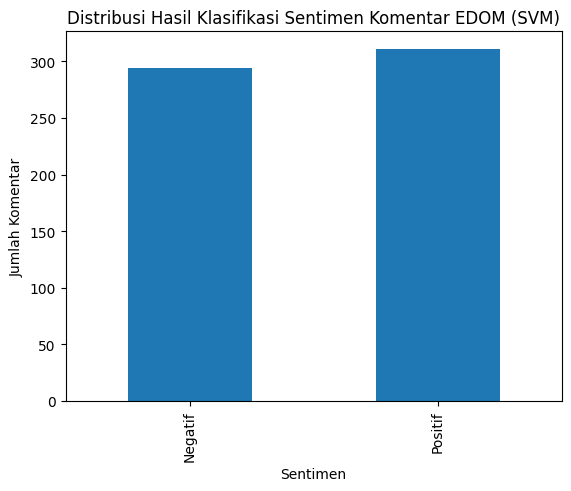

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# Prediksi menggunakan model terbaik (SVM)
# ============================================
y_pred_best = svm_model.predict(X_test_embed)

# ============================================
# Hitung distribusi sentimen
# 0 = negatif, 1 = positif
# ============================================
sentiment_counts = pd.Series(y_pred_best).value_counts().sort_index()
sentiment_counts.index = ["Negatif", "Positif"]

# ============================================
# Visualisasi distribusi sentimen
# ============================================
plt.figure()
sentiment_counts.plot(kind="bar")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Komentar")
plt.title("Distribusi Hasil Klasifikasi Sentimen Komentar EDOM (SVM)")
plt.show()

#### **5.2 Simpan Model SVM & Naive Bayes**

In [ ]:
import joblib
import os

# ============================================================
# Folder tujuan penyimpanan model
# ============================================================
MODEL_DIR = "/content/drive/My Drive/SEMESTER 7/Capstone Project/projects/models/all_models/"
os.makedirs(MODEL_DIR, exist_ok=True)

print("Folder penyimpanan model:", MODEL_DIR)


# ============================================================
# Path file untuk 2 model * 2 format (PKL + JOBLIB)
# ============================================================

# --- SVM ---
SVM_PKL_PATH    = os.path.join(MODEL_DIR, "edom_indobert_svm_all.pkl")
SVM_JOBLIB_PATH = os.path.join(MODEL_DIR, "edom_indobert_svm_all.joblib")

# --- Naive Bayes ---
NB_PKL_PATH     = os.path.join(MODEL_DIR, "edom_indobert_naivebayes_all.pkl")
NB_JOBLIB_PATH  = os.path.join(MODEL_DIR, "edom_indobert_naivebayes_all.joblib")


# ============================================================
# Save model SVM (dua versi)
# ============================================================
if 'svm_model' in globals():
    joblib.dump(svm_model, SVM_PKL_PATH)
    joblib.dump(svm_model, SVM_JOBLIB_PATH)

    print(f"✔ Model SVM disimpan ke:\n  - {SVM_PKL_PATH}\n  - {SVM_JOBLIB_PATH}")
else:
    print("❌ Model SVM belum didefinisikan!")


# ============================================================
# Save model Naive Bayes (dua versi)
# ============================================================
if 'gnb_model' in globals():
    joblib.dump(gnb_model, NB_PKL_PATH)
    joblib.dump(gnb_model, NB_JOBLIB_PATH)

    print(f"✔ Model Naive Bayes disimpan ke:\n  - {NB_PKL_PATH}\n  - {NB_JOBLIB_PATH}")
else:
    print("❌ Model Naive Bayes belum didefinisikan!")

Folder penyimpanan model: /content/drive/My Drive/SEMESTER 7/Capstone Project/projects/models/all_models/
✔ Model SVM disimpan ke:
  - /content/drive/My Drive/SEMESTER 7/Capstone Project/projects/models/all_models/edom_indobert_svm_all.pkl
  - /content/drive/My Drive/SEMESTER 7/Capstone Project/projects/models/all_models/edom_indobert_svm_all.joblib
✔ Model Naive Bayes disimpan ke:
  - /content/drive/My Drive/SEMESTER 7/Capstone Project/projects/models/all_models/edom_indobert_naivebayes_all.pkl
  - /content/drive/My Drive/SEMESTER 7/Capstone Project/projects/models/all_models/edom_indobert_naivebayes_all.joblib


#### **5.3 Uji Coba Klasifikasi Sentimen**

In [ ]:
# Fungsi bantuan untuk prediksi sentimen
import numpy as np

label_id_to_name = {0: "negatif", 1: "positif"}

def predict_sentiment(texts, model="svm"):
    """
    Parameter:
      - texts: string atau list of string
      - model: 'svm' atau 'nb'

    Return:
      list of dict {
        teks_asli,
        teks_bersih,
        label_id,
        label
      }
    """

    # Validasi parameter
    if model not in ["svm", "nb"]:
        raise ValueError("Parameter model harus 'svm' atau 'nb'.")

    # Jika input satu string → ubah jadi list
    if isinstance(texts, str):
        texts = [texts]

    # Cleaning teks (harus sama seperti saat training)
    cleaned_texts = [basic_text_cleaning(t) for t in texts]

    # Encode embedding IndoBERT
    embeds = sbert_model.encode(
        cleaned_texts,
        batch_size=32,
        convert_to_numpy=True,
        device=device,
        show_progress_bar=False
    )

    # Pilih model prediksi
    if model == "svm":
        preds = svm_model.predict(embeds)
    elif model == "nb":
        preds = gnb_model.predict(embeds)

    # Format hasil
    results = []
    for original, clean, label_id in zip(texts, cleaned_texts, preds):
        results.append({
            "teks_asli": original,
            "teks_bersih": clean,
            "label_id": int(label_id),
            "label": label_id_to_name[int(label_id)],
            "model": model.upper()
        })

    return results

#### **5.3.1 Uji dengan data test**

In [ ]:
# fungsi cleaning teks
import re
def basic_text_cleaning(text: str) -> str:
    """
    Normalisasi teks untuk komentar EDOM:
    - ubah ke huruf kecil
    - hapus URL
    - hapus karakter non-Latin (Cina, Jepang, Arab, dll) dan simbol/emoji
    - sisakan huruf a-z, angka, dan spasi
    - rapikan spasi berlebih
    """
    # Lowercase
    text = text.lower()

    # Hapus URL
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # Hapus seluruh karakter yang bukan huruf latin, angka, atau spasi
    # [^a-z0-9\s] artinya: selain a-z, 0-9, dan spasi
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Ganti spasi berurutan jadi satu spasi
    text = re.sub(r"\s+", " ", text)

    # Hapus spasi di awal dan akhir
    text = text.strip()

    return text

In [ ]:
import random

# Ambil 10 index acak
idx_sample = random.sample(range(len(X_test_text)), 10)

sample_texts = [X_test_text[i] for i in idx_sample]
sample_true  = [y_test.iloc[i] for i in idx_sample]

print("=================================================")
print("   UJI 10 DATA TEST — PERBANDINGAN SVM & NB")
print("=================================================\n")

# Loop untuk tiap teks
for i, (text, true_lbl) in enumerate(zip(sample_texts, sample_true)):

    # Prediksi SVM
    pred_svm = predict_sentiment(text, model="svm")[0]

    # Prediksi Naive Bayes
    pred_nb  = predict_sentiment(text, model="nb")[0]

    # Label asli dalam string
    true_label_str = label_id_to_name[int(true_lbl)]

    print(f"\n--- Data {i+1} ---")
    print("Teks asli   :", text)
    print("Teks bersih :", pred_svm['teks_bersih'])  # sama untuk kedua model
    print("Label asli  :", true_label_str)

    print("Prediksi SVM:", pred_svm["label"], f"(id = {pred_svm['label_id']})")
    print("Prediksi NB :", pred_nb["label"], f"(id = {pred_nb['label_id']})")
    print("---------------------------------------------")

   UJI 10 DATA TEST — PERBANDINGAN SVM & NB


--- Data 1 ---
Teks asli   : materi pelajaran menarik tentang cloud computing yang relevan di zaman sekarang namun karena dalam 1 kelas terdapat terlalu banyak mahasiswa menjadikan proses praktikum susah sekaligus asdos hanya ada 3 atau 4 orang saja selama praktikum alhasil ketika kami ingin bertanya terkait praktikum susah
Teks bersih : materi pelajaran menarik tentang cloud computing yang relevan di zaman sekarang namun karena dalam 1 kelas terdapat terlalu banyak mahasiswa menjadikan proses praktikum susah sekaligus asdos hanya ada 3 atau 4 orang saja selama praktikum alhasil ketika kami ingin bertanya terkait praktikum susah
Label asli  : negatif
Prediksi SVM: negatif (id = 0)
Prediksi NB : negatif (id = 0)
---------------------------------------------

--- Data 2 ---
Teks asli   : terima kasih bu
Teks bersih : terima kasih bu
Label asli  : positif
Prediksi SVM: positif (id = 1)
Prediksi NB : positif (id = 1)
---------------------------

#### **5.3.2 Uji dengan input manual**

In [ ]:
user_text = input("Masukkan komentar EDOM: ")

# Prediksi dengan dua model
result_svm = predict_sentiment(user_text, model="svm")[0]
result_nb  = predict_sentiment(user_text, model="nb")[0]

print("\n================== HASIL KLASIFIKASI ==================")
print("Teks asli   :", user_text)
print("Teks bersih :", result_svm["teks_bersih"])  # sama utk NB karena fungsi clean sama

print("\n--- Prediksi SVM ---")
print("Model       : SVM")
print("Prediksi    :", result_svm["label"], f"(label_id = {result_svm['label_id']})")

print("\n--- Prediksi Naive Bayes ---")
print("Model       : Naive Bayes")
print("Prediksi    :", result_nb["label"], f"(label_id = {result_nb['label_id']})")

print("========================================================")

Masukkan komentar EDOM: dosennya sering ghosting mahasiswa

================== HASIL KLASIFIKASI ==================
Teks asli   : dosennya sering ghosting mahasiswa
Teks bersih : dosennya sering ghosting mahasiswa

--- Prediksi SVM ---
Model       : SVM
Prediksi    : negatif (label_id = 0)

--- Prediksi Naive Bayes ---
Model       : Naive Bayes
Prediksi    : negatif (label_id = 0)


In [ ]:
user_text = input("Masukkan komentar EDOM: ")

# Prediksi dengan dua model
result_svm = predict_sentiment(user_text, model="svm")[0]
result_nb  = predict_sentiment(user_text, model="nb")[0]

print("\n================== HASIL KLASIFIKASI ==================")
print("Teks asli   :", user_text)
print("Teks bersih :", result_svm["teks_bersih"])  # sama utk NB karena fungsi clean sama

print("\n--- Prediksi SVM ---")
print("Model       : SVM")
print("Prediksi    :", result_svm["label"], f"(label_id = {result_svm['label_id']})")

print("\n--- Prediksi Naive Bayes ---")
print("Model       : Naive Bayes")
print("Prediksi    :", result_nb["label"], f"(label_id = {result_nb['label_id']})")

print("========================================================")

Masukkan komentar EDOM: dosennya friendly & humble banget

================== HASIL KLASIFIKASI ==================
Teks asli   : dosennya friendly & humble banget
Teks bersih : dosennya friendly humble banget

--- Prediksi SVM ---
Model       : SVM
Prediksi    : positif (label_id = 1)

--- Prediksi Naive Bayes ---
Model       : Naive Bayes
Prediksi    : positif (label_id = 1)


In [ ]:
user_text = input("Masukkan komentar EDOM: ")

# Prediksi dengan dua model
result_svm = predict_sentiment(user_text, model="svm")[0]
result_nb  = predict_sentiment(user_text, model="nb")[0]

print("\n================== HASIL KLASIFIKASI ==================")
print("Teks asli   :", user_text)
print("Teks bersih :", result_svm["teks_bersih"])  # sama utk NB karena fungsi clean sama

print("\n--- Prediksi SVM ---")
print("Model       : SVM")
print("Prediksi    :", result_svm["label"], f"(label_id = {result_svm['label_id']})")

print("\n--- Prediksi Naive Bayes ---")
print("Model       : Naive Bayes")
print("Prediksi    :", result_nb["label"], f"(label_id = {result_nb['label_id']})")

print("========================================================")

Masukkan komentar EDOM: dosennya asik tp tugasnya banyak huhu

================== HASIL KLASIFIKASI ==================
Teks asli   : dosennya asik tp tugasnya banyak huhu
Teks bersih : dosennya asik tp tugasnya banyak huhu

--- Prediksi SVM ---
Model       : SVM
Prediksi    : positif (label_id = 1)

--- Prediksi Naive Bayes ---
Model       : Naive Bayes
Prediksi    : positif (label_id = 1)


## **Demonstrasi Proyek**

### **Setup & Load Dataset (clean-balanced)**

In [ ]:
# 1. Import library
import pandas as pd
import numpy as np
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
import joblib
import os
import torch

# 2. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 3. Load dataset hasil cleaning & balancing
DATASET_PATH = "/content/drive/My Drive/SEMESTER 7/Capstone Project/projects/datasets/edom/edom-2024-clean-balanced.csv"
df = pd.read_csv(DATASET_PATH)
print("Ukuran dataset:", df.shape)
print("\nNama kolom:")
print(df.columns.tolist())
kolom_tampil = [
    "periode",
    "mata_kuliah",
    "program studi",
    "komentar",
    "komentar_cleaned",
    "sentiment_label",  # label positif/negatif
    "label"             # label numerik (0/1)
]

# 4. Tampilkan 5 baris pertama
print("\nTampilan dataset (kolom aman):")
display(df[kolom_tampil].head())

Mounted at /content/drive
Ukuran dataset: (3022, 14)

Nama kolom:
['periode', 'nama_dosen', 'mata_kuliah', 'program studi', 'kategori_komentar', 'komentar', 'label_sentimen', 'comment_length_chars', 'komentar_cleaned', 'word_count', 'sentiment_model_label_raw', 'sentiment_model_score', 'sentiment_label', 'label']

Tampilan dataset (kolom aman):


,periode,mata_kuliah,program studi,komentar,komentar_cleaned,sentiment_label,label
0,2024-2,keamanan komputer dan jaringan,teknik informatika,"Terima kasih pak, sehat terus dan semoga ilmun...",terima kasih pak sehat terus dan semoga ilmuny...,positif,1
1,2024-1,natural language processing,teknik informatika,Mata Kuliah ini sudah berjalan dengan sangat baik,mata kuliah ini sudah berjalan dengan sangat baik,positif,1
2,2024-2,jaringan komputer,sistem informasi,Seru dan Asik,seru dan asik,positif,1
3,2024-1,rekayasa perangkat lunak,teknik informatika,"Sangat baik, semangat Bu Tiffany. Terimakasih ...",sangat baik semangat bu tiffany terimakasih at...,positif,1
4,2024-1,sistem informasi geografis,teknik informatika,Dosen sebaiknya upload materi terlebih dahulu ...,dosen sebaiknya upload materi terlebih dahulu ...,positif,1


In [ ]:
# 4. Kolom teks & label untuk modeling
TEXT_COLUMN = "komentar_cleaned"   # fitur teks
LABEL_COLUMN = "label"             # target numerik (0/1)
X_text = df[TEXT_COLUMN].astype(str).tolist()
y = df[LABEL_COLUMN].astype(int)

# Split data train & test
from sklearn.model_selection import train_test_split
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Jumlah data training :", len(X_train_text))
print("Jumlah data testing  :", len(X_test_text))

Jumlah data training : 2417
Jumlah data testing  : 605


#### **Load IndoBERT SBERT & Buat Embedding untuk Data Uji**

In [ ]:
# 5. Install & load SentenceTransformer (IndoBERT SBERT)
!pip install -q sentence-transformers
from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL_NAME = "firqaaa/indo-sentence-bert-base"
sbert_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
device = "cuda" if torch.cuda.is_available() else "cpu"
sbert_model.to(device)

print("Model embedding:", EMBEDDING_MODEL_NAME)
print("Perangkat:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/118 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model embedding: firqaaa/indo-sentence-bert-base
Perangkat: cuda


In [ ]:
# 6. Fungsi helper untuk encode teks -> embedding
def encode_texts(model, texts, batch_size=32):
    embeddings = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        device=device
    )
    return embeddings

# Generate embedding untuk data test
X_test_embed = encode_texts(sbert_model, X_test_text, batch_size=32)
print("Shape embedding test:", X_test_embed.shape)

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Shape embedding test: (605, 768)


### **Load Models (SVM & Naive Bayes)**

In [ ]:
# 7. Load model SVM & Naive Bayes dari Drive
MODEL_DIR = "/content/drive/My Drive/SEMESTER 7/Capstone Project/projects/models/all_models/"

SVM_JOBLIB_PATH = os.path.join(MODEL_DIR, "edom_indobert_svm_all.joblib")
NB_JOBLIB_PATH  = os.path.join(MODEL_DIR, "edom_indobert_naivebayes_all.joblib")

svm_model = joblib.load(SVM_JOBLIB_PATH)
gnb_model = joblib.load(NB_JOBLIB_PATH)

print("✔ Model SVM & Naive Bayes berhasil dimuat.")

✔ Model SVM & Naive Bayes berhasil dimuat.


### **Evaluasi Performa Model**

In [ ]:
# 8. Fungsi evaluasi model
label_id_to_name = {0: "negatif", 1: "positif"}

def evaluate_model(model_name, model, X_test_embed, y_test):
    # Prediksi
    y_pred = model.predict(X_test_embed)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    # Precision, Recall, F1 per kelas (0 = negatif, 1 = positif)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test,
        y_pred,
        labels=[0, 1],
        zero_division=0
    )

    print(f"\n==============================")
    print(f"=== Evaluasi Model: {model_name} ===")
    print(f"==============================")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision (negatif, positif): {np.round(precision, 4)}")
    print(f"Recall    (negatif, positif): {np.round(recall, 4)}")
    print(f"F1-score  (negatif, positif): {np.round(f1, 4)}")

    print("\n--- Classification Report ---")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["negatif", "positif"],
            zero_division=0
        )
    )

    # Confusion Matrix
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    cm_df = pd.DataFrame(
        cm,
        index=["Actual Negatif", "Actual Positif"],
        columns=["Pred Negatif", "Pred Positif"]
    )

    print("\n--- Confusion Matrix ---")
    display(cm_df)

    # ringkasan metrik
    return {
        "model": model_name,
        "accuracy": acc,
        "precision_neg": precision[0],
        "precision_pos": precision[1],
        "recall_neg": recall[0],
        "recall_pos": recall[1],
        "f1_neg": f1[0],
        "f1_pos": f1[1],
    }

# 9. Panggil evaluasi untuk kedua model
results = []
results.append(evaluate_model("IndoBERT + LinearSVC (SVM)", svm_model, X_test_embed, y_test))
results.append(evaluate_model("IndoBERT + GaussianNB", gnb_model, X_test_embed, y_test))

comparison_df = pd.DataFrame(results)
print("\n==============================")
print("Ringkasan Perbandingan Model")
print("==============================")
display(comparison_df)


=== Evaluasi Model: IndoBERT + LinearSVC (SVM) ===
Accuracy  : 0.9388
Precision (negatif, positif): [0.9524 0.926 ]
Recall    (negatif, positif): [0.9241 0.9536]
F1-score  (negatif, positif): [0.938  0.9396]

--- Classification Report ---
              precision    recall  f1-score   support

     negatif       0.95      0.92      0.94       303
     positif       0.93      0.95      0.94       302

    accuracy                           0.94       605
   macro avg       0.94      0.94      0.94       605
weighted avg       0.94      0.94      0.94       605


--- Confusion Matrix ---


,Pred Negatif,Pred Positif
Actual Negatif,280,23
Actual Positif,14,288



=== Evaluasi Model: IndoBERT + GaussianNB ===
Accuracy  : 0.9240
Precision (negatif, positif): [0.8954 0.9571]
Recall    (negatif, positif): [0.9604 0.8874]
F1-score  (negatif, positif): [0.9268 0.921 ]

--- Classification Report ---
              precision    recall  f1-score   support

     negatif       0.90      0.96      0.93       303
     positif       0.96      0.89      0.92       302

    accuracy                           0.92       605
   macro avg       0.93      0.92      0.92       605
weighted avg       0.93      0.92      0.92       605


--- Confusion Matrix ---


,Pred Negatif,Pred Positif
Actual Negatif,291,12
Actual Positif,34,268



Ringkasan Perbandingan Model


,model,accuracy,precision_neg,precision_pos,recall_neg,recall_pos,f1_neg,f1_pos
0,IndoBERT + LinearSVC (SVM),0.938843,0.952381,0.926045,0.924092,0.953642,0.938023,0.939641
1,IndoBERT + GaussianNB,0.923967,0.895385,0.957143,0.960396,0.887417,0.926752,0.920962


### **Fungsi Cleaning Text & Klasifikasi Sentimen**

In [ ]:
# 10. Fungsi cleaning teks
import re
def basic_text_cleaning(text: str) -> str:
    """
    Normalisasi teks untuk komentar EDOM:
    - ubah ke huruf kecil
    - hapus URL
    - hapus karakter non-Latin dan simbol/emoji
    - sisakan huruf a-z, angka, dan spasi
    - rapikan spasi berlebih
    """
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

# 11. Fungsi klasifikasi sentimen untuk 1 atau banyak teks
label_id_to_name = {0: "negatif", 1: "positif"}
def predict_sentiment(texts, model="svm"):
    """
    texts : string atau list of string
    model : 'svm' atau 'nb'
    """
    if model not in ["svm", "nb"]:
        raise ValueError("Parameter model harus 'svm' atau 'nb'.")
    # pastikan berupa list
    if isinstance(texts, str):
        texts = [texts]
    cleaned_texts = [basic_text_cleaning(t) for t in texts]
    # embedding dengan IndoBERT SBERT
    embeds = sbert_model.encode(
        cleaned_texts,
        batch_size=32,
        convert_to_numpy=True,
        device=device,
        show_progress_bar=False
    )
    if model == "svm":
        preds = svm_model.predict(embeds)
    else:
        preds = gnb_model.predict(embeds)
    results = []
    for original, clean, label_id in zip(texts, cleaned_texts, preds):
        results.append({
            "teks_asli": original,
            "teks_bersih": clean,
            "label_id": int(label_id),
            "label": label_id_to_name[int(label_id)],
            "model": model.upper()
        })
    return results

### **Uji Klasifikasi dengan Data Test**

In [ ]:
import random

print("=================================================")
print("   UJI 10 DATA TEST — PERBANDINGAN SVM & NB")
print("=================================================\n")

# Ambil 10 index acak dari data test
idx_sample = random.sample(range(len(X_test_text)), 10)

sample_texts = [X_test_text[i] for i in idx_sample]
sample_true  = [y_test.iloc[i] for i in idx_sample]

# Loop untuk tiap teks
for i, (text, true_lbl) in enumerate(zip(sample_texts, sample_true), start=1):

    # Prediksi SVM
    pred_svm = predict_sentiment(text, model="svm")[0]

    # Prediksi Naive Bayes
    pred_nb  = predict_sentiment(text, model="nb")[0]

    # Label asli dalam bentuk string
    true_label_str = label_id_to_name[int(true_lbl)]

    print(f"\n--- Data {i} ---")
    print("Teks asli   :", text)
    print("Teks bersih :", pred_svm['teks_bersih'])  # sama untuk kedua model
    print("Label asli  :", true_label_str)

    print("Klasifikasi SVM:", pred_svm["label"], f"(id = {pred_svm['label_id']})")
    print("Klasifikasi NB :", pred_nb["label"], f"(id = {pred_nb['label_id']})")
    print("---------------------------------------------")

   UJI 10 DATA TEST — PERBANDINGAN SVM & NB


--- Data 1 ---
Teks asli   : sudah bagus sebenernya cuman kurang pas project showcase aja uas terlalu cepat
Teks bersih : sudah bagus sebenernya cuman kurang pas project showcase aja uas terlalu cepat
Label asli  : negatif
Klasifikasi SVM: negatif (id = 0)
Klasifikasi NB : negatif (id = 0)
---------------------------------------------

--- Data 2 ---
Teks asli   : basdat asik pokoknya mah
Teks bersih : basdat asik pokoknya mah
Label asli  : positif
Klasifikasi SVM: positif (id = 1)
Klasifikasi NB : positif (id = 1)
---------------------------------------------

--- Data 3 ---
Teks asli   : saran untuk diadakan kelas offline karena jika online terkadang kurang kondusif
Teks bersih : saran untuk diadakan kelas offline karena jika online terkadang kurang kondusif
Label asli  : negatif
Klasifikasi SVM: negatif (id = 0)
Klasifikasi NB : negatif (id = 0)
---------------------------------------------

--- Data 4 ---
Teks asli   : terlalu banyak in

### **Perbadingan Klasifikasi dengan Data Test**

In [ ]:
# ============================================
# Analisis perbandingan prediksi SVM vs NB
# ============================================

# Prediksi seluruh data test
y_pred_svm = svm_model.predict(X_test_embed)
y_pred_nb  = gnb_model.predict(X_test_embed)

# Buat dataframe analisis
df_analysis = pd.DataFrame({
    "komentar": X_test_text,
    "label_aktual": y_test.values,
    "pred_svm": y_pred_svm,
    "pred_nb": y_pred_nb
})

# mapping label numerik -> teks
label_map = {0: "negatif", 1: "positif"}

df_analysis["label_aktual"] = df_analysis["label_aktual"].map(label_map)
df_analysis["pred_svm"] = df_analysis["pred_svm"].map(label_map)
df_analysis["pred_nb"] = df_analysis["pred_nb"].map(label_map)

print("Jumlah data test:", len(df_analysis))
display(df_analysis.head())

Jumlah data test: 605


,komentar,label_aktual,pred_svm,pred_nb
0,semoga lebih baik lagi,positif,positif,positif
1,lebih mendalam lagi dalam prakteknya,negatif,positif,negatif
2,kalau bisa pak rio sering sering masuk ke kela...,negatif,negatif,negatif
3,seru dan asik,positif,positif,positif
4,untuk dosen harapannya pada saat praktik adala...,negatif,positif,negatif


In [ ]:
# ============================================
# Kategori perbandingan model
# ============================================

def compare_models(row):
    if row["pred_svm"] == row["label_aktual"] and row["pred_nb"] == row["label_aktual"]:
        return "keduanya_benar"
    elif row["pred_svm"] == row["label_aktual"] and row["pred_nb"] != row["label_aktual"]:
        return "svm_benar_nb_salah"
    elif row["pred_svm"] != row["label_aktual"] and row["pred_nb"] == row["label_aktual"]:
        return "nb_benar_svm_salah"
    else:
        return "keduanya_salah"

df_analysis["kategori"] = df_analysis.apply(compare_models, axis=1)

print("\nDistribusi kategori prediksi:")
print(df_analysis["kategori"].value_counts())


Distribusi kategori prediksi:
kategori
keduanya_benar        540
svm_benar_nb_salah     28
nb_benar_svm_salah     19
keduanya_salah         18
Name: count, dtype: int64


In [ ]:
# Ambil kasus SVM benar tetapi NB salah
df_svm_correct_nb_wrong = df_analysis[
    df_analysis["kategori"] == "svm_benar_nb_salah"
]

print("Jumlah kasus SVM benar tapi NB salah:", len(df_svm_correct_nb_wrong))
display(df_svm_correct_nb_wrong.head(10))

Jumlah kasus SVM benar tapi NB salah: 28


,komentar,label_aktual,pred_svm,pred_nb,kategori
49,peran penting dalam dunia percodingan,positif,positif,negatif,svm_benar_nb_salah
70,seru sekali belajar manpro bisa berkelompok de...,positif,positif,negatif,svm_benar_nb_salah
93,yang semangat ngajarnya pak jangan terlalu kaku,negatif,negatif,positif,svm_benar_nb_salah
117,segi penyampaian materi yang jelas dan mudah d...,positif,positif,negatif,svm_benar_nb_salah
128,materi yang baik dan selalu tepat waktu untuk ...,positif,positif,negatif,svm_benar_nb_salah
148,materi lebih up to date dengan jamannya,positif,positif,negatif,svm_benar_nb_salah
160,lebih di manfaatkan lagi waktu di pertemuanya ...,positif,positif,negatif,svm_benar_nb_salah
166,saran dari saya mungkin tidak ada karena apa y...,positif,positif,negatif,svm_benar_nb_salah
201,mata kuliah sangat menarik tetapi terlalu berf...,negatif,negatif,positif,svm_benar_nb_salah
212,matkul yang menantang dan menarikk,positif,positif,negatif,svm_benar_nb_salah


In [ ]:
# Simpan ke Excel untuk analisis paper
OUTPUT_PATH = "/content/drive/My Drive/SEMESTER 7/Capstone Project/projects/datasets/edom/perbandingan-klasifikasi-data-uji.xlsx"

df_analysis.to_excel(OUTPUT_PATH, index=False)

print("File analisis berhasil disimpan di:")
print(OUTPUT_PATH)

File analisis berhasil disimpan di:
/content/drive/My Drive/SEMESTER 7/Capstone Project/projects/datasets/edom/perbandingan-klasifikasi-data-uji.xlsx


### **Uji Klasifikasi dengan Inputan**

In [ ]:
print("=======================================")
print("   Uji Klasifikasi (3 input)")
print("=======================================\n")

for i in range(1, 4):  # loop 3 kali
    user_text = input(f"Masukkan komentar EDOM ke-{i}: ")

    # Jika user cuma tekan enter → dianggap berhenti
    if user_text.strip() == "":
        print("Input kosong, demo dihentikan.")
        break

    # Klasifikasi dengan dua model
    result_svm = predict_sentiment(user_text, model="svm")[0]
    result_nb  = predict_sentiment(user_text, model="nb")[0]

    print("\n================== HASIL KLASIFIKASI ==================")
    print(f"Input ke-{i}")
    print("Teks asli   :", user_text)
    print("Teks bersih :", result_svm["teks_bersih"])

    print("\n--- Klasifikasi SVM ---")
    print("Model       : SVM")
    print("Klasifikasi    :", result_svm["label"], f"(label_id = {result_svm['label_id']})")

    print("\n--- Klasifikasi Naive Bayes ---")
    print("Model       : Naive Bayes")
    print("Klasifikasi    :", result_nb["label"], f"(label_id = {result_nb['label_id']})")

    print("========================================================\n")

   Uji Klasifikasi (3 input)

Masukkan komentar EDOM ke-1: mengajarnya lebih interaktif lagi pak

================== HASIL KLASIFIKASI ==================
Input ke-1
Teks asli   : mengajarnya lebih interaktif lagi pak
Teks bersih : mengajarnya lebih interaktif lagi pak

--- Klasifikasi SVM ---
Model       : SVM
Klasifikasi    : negatif (label_id = 0)

--- Klasifikasi Naive Bayes ---
Model       : Naive Bayes
Klasifikasi    : positif (label_id = 1)

Masukkan komentar EDOM ke-2: respect sama dosen yang sabar dalam menghadapi mahasiwanya

================== HASIL KLASIFIKASI ==================
Input ke-2
Teks asli   : respect sama dosen yang sabar dalam menghadapi mahasiwanya
Teks bersih : respect sama dosen yang sabar dalam menghadapi mahasiwanya

--- Klasifikasi SVM ---
Model       : SVM
Klasifikasi    : positif (label_id = 1)

--- Klasifikasi Naive Bayes ---
Model       : Naive Bayes
Klasifikasi    : positif (label_id = 1)

Masukkan komentar EDOM ke-3: ga adaa, all good pak

===========